# Healthcare Accessibility Analysis in Casablanca
## Time-Based Public Transport Accessibility Assessment

**Capstone Project:** Analyzing accessibility to healthcare services using public transport in Casablanca

**Approach:** Time-based accessibility analysis (isochrone method) rather than fixed-distance buffers

---

### Objectives:
1. Analyze spatial distribution of healthcare facilities and transport stops
2. Calculate time-based accessibility metrics from population centers
3. Identify underserved areas with poor healthcare accessibility
4. Generate accessibility scores for each district
5. Visualize accessibility patterns and equity gaps

---

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, LineString, Polygon
from scipy.spatial import cKDTree
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import folium
from folium import plugins
import plotly.express as px
import plotly.graph_objects as go

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Data file paths
DATA_DIR = '../data/processed/'

# Load GeoPackage files
print("Loading geospatial datasets...")
districts_gdf = gpd.read_file(DATA_DIR + 'Casablanca_Districts.gpkg')
healthcare_gdf = gpd.read_file(DATA_DIR + 'Casablanca_Healthcare.gpkg')
transport_gdf = gpd.read_file(DATA_DIR + 'Casablanca_Transport_Stops.gpkg')
population_gdf = gpd.read_file(DATA_DIR + 'population_by_districts.gpkg')

print(f"✓ Districts: {len(districts_gdf)} features")
print(f"✓ Healthcare facilities: {len(healthcare_gdf)} features")
print(f"✓ Transport stops: {len(transport_gdf)} features")
print(f"✓ Population data: {len(population_gdf)} features")

Loading geospatial datasets...
✓ Districts: 34 features
✓ Healthcare facilities: 84 features
✓ Transport stops: 1463 features
✓ Population data: 34 features


## 2. Exploratory Data Analysis

In [3]:
# Examine district data
print("=" * 60)
print("DISTRICT DATA")
print("=" * 60)
print(f"\nShape: {districts_gdf.shape}")
print(f"\nColumns: {districts_gdf.columns.tolist()}")
print(f"\nCRS: {districts_gdf.crs}")
print(f"\nFirst few rows:")
display(districts_gdf.head())
print(f"\nGeometry types: {districts_gdf.geometry.type.value_counts()}")

DISTRICT DATA

Shape: (34, 4)

Columns: ['district', 'commune', 'commune_type_encoded', 'geometry']

CRS: EPSG:4326

First few rows:


,district,commune,commune_type_encoded,geometry
0,Bouskoura,Bouskoura,0,"MULTIPOLYGON (((-7.68792 33.41272, -7.68806 33..."
1,Bouskoura,Dar Bouazza,0,"MULTIPOLYGON (((-7.76684 33.45884, -7.77442 33..."
2,Mediouna,El Majjatia Oulad Taleb,0,"MULTIPOLYGON (((-7.52672 33.40465, -7.52772 33..."
3,Mediouna,Lahraouyine,0,"MULTIPOLYGON (((-7.4977 33.50524, -7.50182 33...."
4,Ahl Laghlam,Ahl Laghlam,1,"MULTIPOLYGON (((-7.49482 33.55348, -7.50156 33..."



Geometry types: MultiPolygon    34
Name: count, dtype: int64


In [4]:
# Examine healthcare data
print("=" * 60)
print("HEALTHCARE FACILITIES DATA")
print("=" * 60)
print(f"\nShape: {healthcare_gdf.shape}")
print(f"\nColumns: {healthcare_gdf.columns.tolist()}")
print(f"\nCRS: {healthcare_gdf.crs}")
print(f"\nFirst few rows:")
display(healthcare_gdf.head())

# Extract facility types if available
if 'name' in healthcare_gdf.columns:
    print(f"\nSample facility names:")
    print(healthcare_gdf['name'].head(10).tolist())

HEALTHCARE FACILITIES DATA

Shape: (84, 4)

Columns: ['name', 'latitude', 'longitude', 'geometry']

CRS: EPSG:4326

First few rows:


,name,latitude,longitude,geometry
0,clinique badr,33.594870,-7.641098,POINT (-7.6411 33.59487)
1,hôpital sidi othmane,33.558542,-7.573301,POINT (-7.5733 33.55854)
2,polyclinique cnss,33.540515,-7.597635,POINT (-7.59764 33.54051)
3,clinique abdelmoumen,33.565221,-7.627531,POINT (-7.62753 33.56522)
4,avicenne,33.554351,-7.610911,POINT (-7.61091 33.55435)



Sample facility names:
['clinique badr', 'hôpital sidi othmane', 'polyclinique cnss', 'clinique abdelmoumen', 'avicenne', 'clinique bournazel', 'clinique zarhoun', 'clinique les princes', 'clinique hamdani', 'clinique hermitage']


In [5]:
# Examine transport stops data
print("=" * 60)
print("TRANSPORT STOPS DATA")
print("=" * 60)
print(f"\nShape: {transport_gdf.shape}")
print(f"\nColumns: {transport_gdf.columns.tolist()}")
print(f"\nCRS: {transport_gdf.crs}")
print(f"\nFirst few rows:")
display(transport_gdf.head())

# Analyze transport modes
if 'mode' in transport_gdf.columns:
    print(f"\nTransport modes:")
    print(transport_gdf['mode'].value_counts())

TRANSPORT STOPS DATA

Shape: (1463, 7)

Columns: ['cluster_id', 'stop_name', 'Lines', 'mode', 'longitude', 'latitude', 'geometry']

CRS: EPSG:4326

First few rows:


,cluster_id,stop_name,Lines,mode,longitude,latitude,geometry
0,0,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633955,33.592059,POINT (-7.63395 33.59206)
1,1,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633524,33.592137,POINT (-7.63352 33.59214)
2,2,4EME ARRONDISSEMENT,"['L604', 'L067', 'L072']",['casabus'],-7.572611,33.557130,POINT (-7.57261 33.55713)
3,3,4EME ARRONDISSEMENT,"['L604', 'L067', 'L072']",['casabus'],-7.573472,33.557659,POINT (-7.57347 33.55766)
4,4,ABATOIRS MUNICIPAUX,"['L055', 'L068']",['casabus'],-7.549733,33.549595,POINT (-7.54973 33.5496)



Transport modes:
mode
['casabus']              1311
['tram']                   96
['busway']                 41
['tram', 'casabus']         8
['casabus', 'tram']         6
['busway', 'casabus']       1
Name: count, dtype: int64


In [6]:
# Examine population data
print("=" * 60)
print("POPULATION DATA")
print("=" * 60)
print(f"\nShape: {population_gdf.shape}")
print(f"\nColumns: {population_gdf.columns.tolist()}")
print(f"\nCRS: {population_gdf.crs}")
print(f"\nFirst few rows:")
display(population_gdf.head())

if 'population' in population_gdf.columns:
    total_pop = population_gdf['population'].sum()
    print(f"\nTotal population: {total_pop:,.0f}")
    print(f"Average district population: {population_gdf['population'].mean():,.0f}")
    print(f"Population statistics:")
    print(population_gdf['population'].describe())

POPULATION DATA

Shape: (34, 3)

Columns: ['commune', 'population', 'geometry']

CRS: EPSG:4326

First few rows:


,commune,population,geometry
0,tit mellil,56019,"MULTIPOLYGON (((-7.48923 33.52544, -7.49853 33..."
1,mediouna,29972,"MULTIPOLYGON (((-7.52353 33.45134, -7.52288 33..."
2,lahraouyine,87977,"MULTIPOLYGON (((-7.4977 33.50524, -7.50182 33...."
3,sidi hajjaj ouad hassar,76362,"MULTIPOLYGON (((-7.377 33.52026, -7.37646 33.5..."
4,el majjatia oulad taleb,95457,"MULTIPOLYGON (((-7.52672 33.40465, -7.52772 33..."



Total population: 5,102,619
Average district population: 150,077
Population statistics:
count        34.000000
mean     150077.029412
std      127862.657164
min       14784.000000
25%       76825.500000
50%      115772.500000
75%      169080.000000
max      551443.000000
Name: population, dtype: float64


## 3. Ensure Consistent CRS and Create Centroids

In [7]:
# Reproject to a metric CRS for distance calculations (UTM Zone 29N for Morocco)
TARGET_CRS = 'EPSG:32629'  # UTM Zone 29N

print(f"Reprojecting all datasets to {TARGET_CRS}...")
districts_gdf = districts_gdf.to_crs(TARGET_CRS)
healthcare_gdf = healthcare_gdf.to_crs(TARGET_CRS)
transport_gdf = transport_gdf.to_crs(TARGET_CRS)
population_gdf = population_gdf.to_crs(TARGET_CRS)

print("✓ All datasets reprojected to metric CRS")

Reprojecting all datasets to EPSG:32629...
✓ All datasets reprojected to metric CRS


In [8]:
# Create district centroids for origin points
districts_gdf['centroid'] = districts_gdf.geometry.centroid
districts_gdf['centroid_x'] = districts_gdf.centroid.x
districts_gdf['centroid_y'] = districts_gdf.centroid.y

# Calculate district area in km²
districts_gdf['area_km2'] = districts_gdf.geometry.area / 1_000_000

print("✓ District centroids created")
print(f"Total study area: {districts_gdf['area_km2'].sum():.2f} km²")

✓ District centroids created
Total study area: 837.67 km²


## 4. Spatial Distribution Visualization

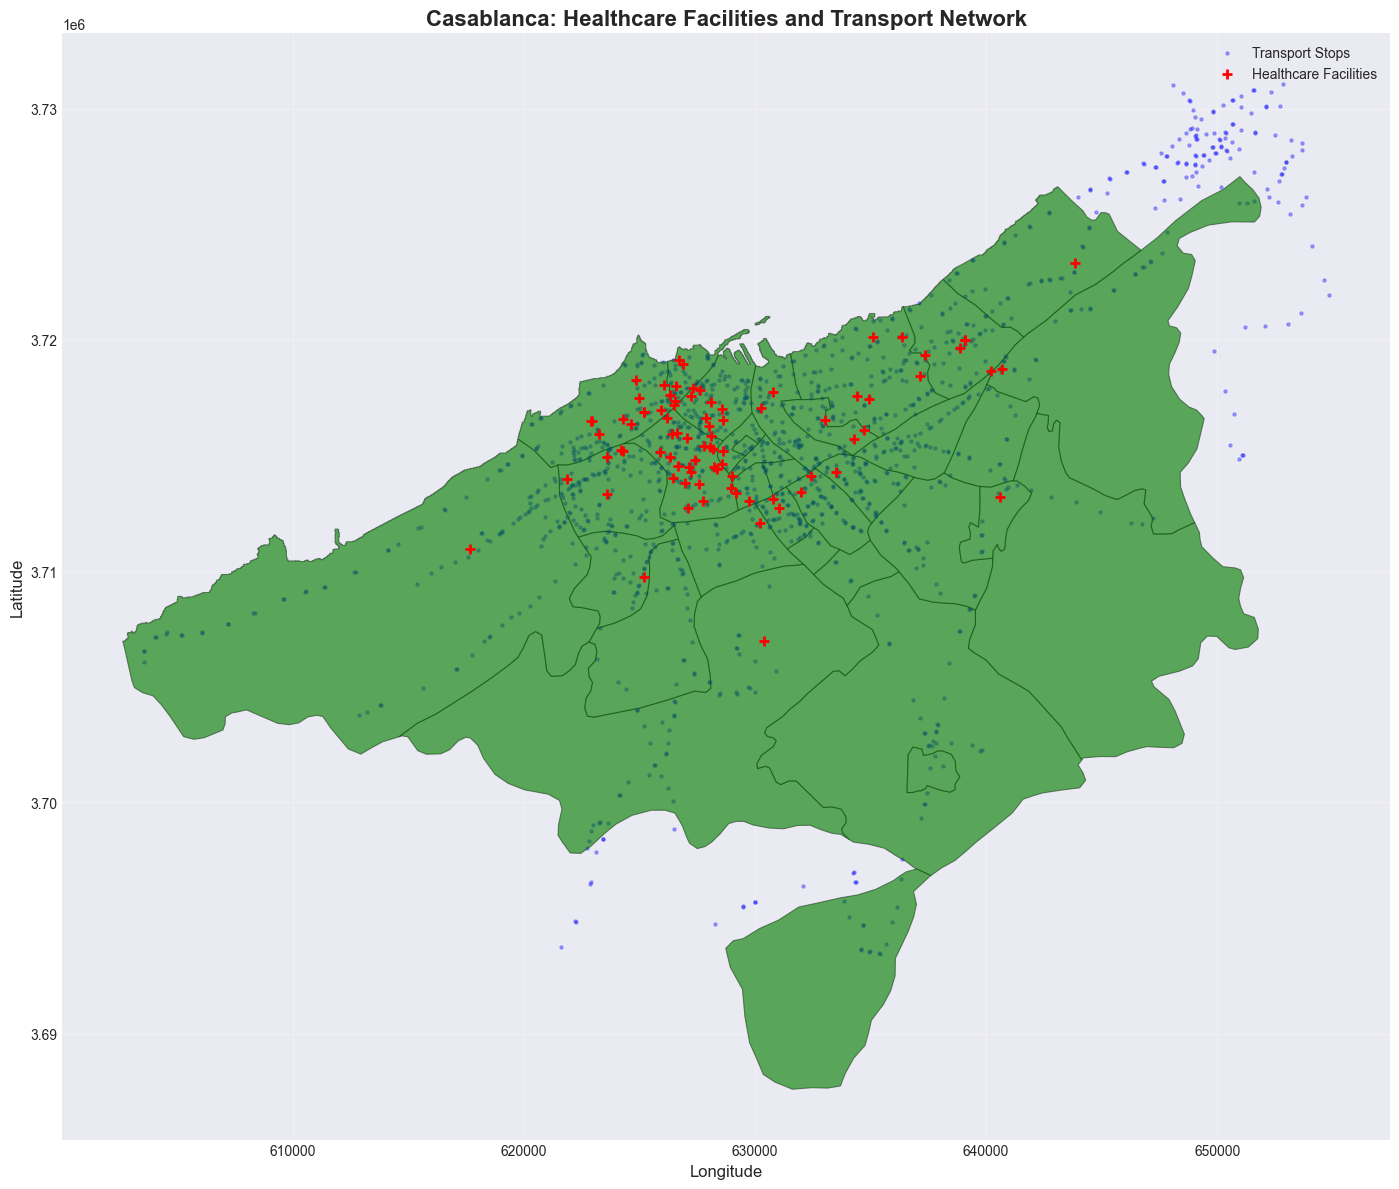

✓ Overview map created


In [9]:
# Create overview map
fig, ax = plt.subplots(figsize=(15, 12))

# Plot districts
districts_gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5, linewidth=0.8)

# Plot transport stops
transport_gdf.plot(ax=ax, color='blue', markersize=5, alpha=0.3, label='Transport Stops')

# Plot healthcare facilities
healthcare_gdf.plot(ax=ax, color='red', markersize=50, marker='+', linewidth=2, 
                     label='Healthcare Facilities', zorder=5)

# Add district centroids
districts_gdf.plot(ax=ax, color='green', markersize=30, marker='o', 
                    alpha=0.6, label='District Centroids', column='centroid')

ax.set_title('Casablanca: Healthcare Facilities and Transport Network', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Overview map created")

Population linked for 34/34 districts (100.0%)


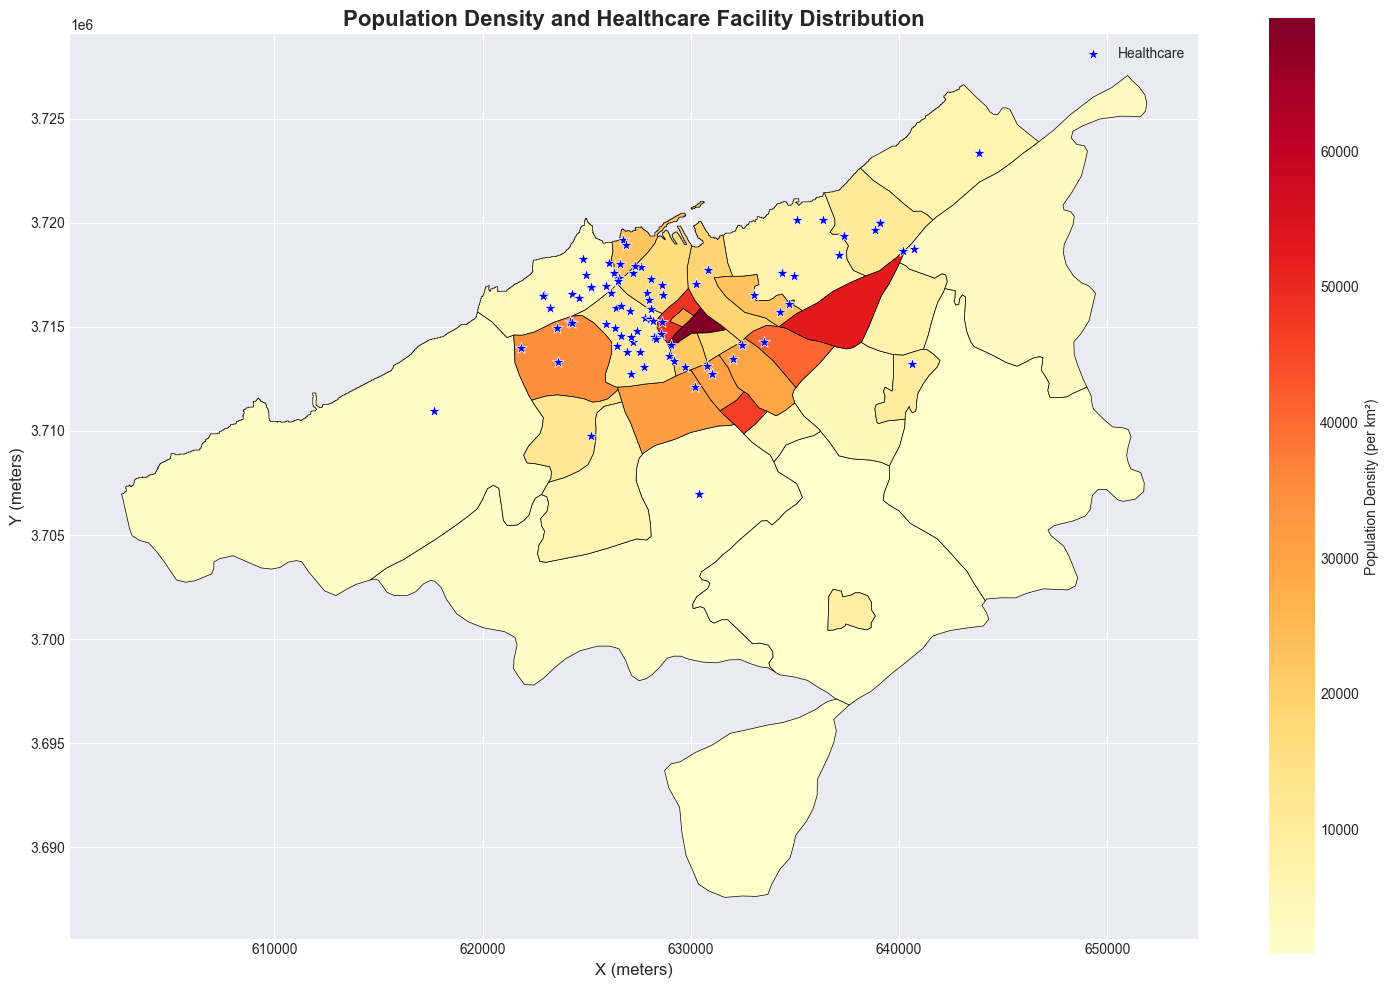

✓ Population density map created


In [10]:
# Population density map
if 'population' in population_gdf.columns:
    # Build robust normalized keys to improve joins between district names
    def _norm_key(series):
        return (
            series.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )

    # Attach population to districts if missing or mostly null
    needs_population_merge = (
        'population' not in districts_gdf.columns
        or districts_gdf['population'].isna().all()
    )

    if needs_population_merge:
        district_key_candidates = ['commune', 'district', 'name', 'nom']
        pop_key_candidates = ['commune', 'district', 'name', 'nom']

        district_key = next((c for c in district_key_candidates if c in districts_gdf.columns), None)
        pop_key = next((c for c in pop_key_candidates if c in population_gdf.columns), None)

        if district_key and pop_key:
            pop_lookup = population_gdf[[pop_key, 'population']].copy()
            pop_lookup['__join_key'] = _norm_key(pop_lookup[pop_key])
            pop_lookup = pop_lookup.drop_duplicates(subset='__join_key', keep='first')

            districts_gdf['__join_key'] = _norm_key(districts_gdf[district_key])
            districts_gdf = districts_gdf.merge(
                pop_lookup[['__join_key', 'population']],
                on='__join_key',
                how='left',
                suffixes=('', '_from_pop')
            )
            districts_gdf = districts_gdf.drop(columns=['__join_key'], errors='ignore')

            # If a population column already existed, prefer original then fallback to merged values
            if 'population_from_pop' in districts_gdf.columns:
                districts_gdf['population'] = districts_gdf['population'].fillna(districts_gdf['population_from_pop'])
                districts_gdf = districts_gdf.drop(columns=['population_from_pop'])

        # Fallback: spatial join if still mostly null after key-based merge
        if 'population' not in districts_gdf.columns or districts_gdf['population'].isna().mean() > 0.7:
            pop_points = gpd.GeoDataFrame(
                population_gdf.drop(columns=['geometry'], errors='ignore').copy(),
                geometry=population_gdf.geometry.centroid,
                crs=population_gdf.crs
            )
            spatial_join = gpd.sjoin(
                districts_gdf[['geometry']].copy(),
                pop_points[['population', 'geometry']],
                how='left',
                predicate='contains'
            )
            districts_gdf['population'] = spatial_join.groupby(spatial_join.index)['population'].first()

    # Report merge quality
    non_null_pop = districts_gdf['population'].notna().sum() if 'population' in districts_gdf.columns else 0
    total_rows = len(districts_gdf)
    print(f'Population linked for {non_null_pop}/{total_rows} districts ({100*non_null_pop/total_rows:.1f}%)')

    # Calculate population density
    districts_gdf['pop_density'] = districts_gdf['population'] / districts_gdf['area_km2']

    fig, ax = plt.subplots(figsize=(15, 12))
    districts_gdf.plot(
        column='pop_density',
        ax=ax,
        legend=True,
        cmap='YlOrRd',
        edgecolor='black',
        linewidth=0.5,
        legend_kwds={'label': 'Population Density (per km²)', 'shrink': 0.8}
    )

    healthcare_gdf.plot(
        ax=ax,
        color='blue',
        markersize=80,
        marker='*',
        edgecolor='white',
        linewidth=0.5,
        label='Healthcare',
        zorder=5
    )

    ax.set_title('Population Density and Healthcare Facility Distribution', fontsize=16, fontweight='bold')
    ax.set_xlabel('X (meters)', fontsize=12)
    ax.set_ylabel('Y (meters)', fontsize=12)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    print('✓ Population density map created')

## 5. Time-Based Accessibility Analysis

### 5.1 Calculate Walking Time to Nearest Transport Stop

In [11]:
# Constants for time calculations
WALKING_SPEED = 5  # km/h (average walking speed)
BUS_SPEED = 20  # km/h (average bus speed in urban areas)
WAIT_TIME = 10  # minutes (average waiting time for bus)
TRANSFER_TIME = 5  # minutes (time penalty for transfers)

# Convert speeds to m/min for calculations
WALKING_SPEED_M_MIN = (WALKING_SPEED * 1000) / 60  # meters per minute
BUS_SPEED_M_MIN = (BUS_SPEED * 1000) / 60  # meters per minute

print(f"Walking speed: {WALKING_SPEED} km/h ({WALKING_SPEED_M_MIN:.1f} m/min)")
print(f"Bus speed: {BUS_SPEED} km/h ({BUS_SPEED_M_MIN:.1f} m/min)")
print(f"Average wait time: {WAIT_TIME} minutes")
print(f"Transfer penalty: {TRANSFER_TIME} minutes")

Walking speed: 5 km/h (83.3 m/min)
Bus speed: 20 km/h (333.3 m/min)
Average wait time: 10 minutes
Transfer penalty: 5 minutes


In [12]:
def calculate_nearest_distances(origins_gdf, destinations_gdf, k=1):
    """
    Calculate distances from origins to k nearest destinations using spatial index.
    
    Parameters:
    -----------
    origins_gdf : GeoDataFrame
        Origin points (e.g., district centroids)
    destinations_gdf : GeoDataFrame
        Destination points (e.g., healthcare facilities, transport stops)
    k : int
        Number of nearest destinations to find
    
    Returns:
    --------
    distances : array
        Distances in meters to k nearest destinations
    indices : array
        Indices of k nearest destinations
    """
    # Extract coordinates
    origin_coords = np.array([(geom.x, geom.y) for geom in origins_gdf.geometry])
    dest_coords = np.array([(geom.x, geom.y) for geom in destinations_gdf.geometry])
    
    # Build spatial index
    tree = cKDTree(dest_coords)
    
    # Query k nearest neighbors
    distances, indices = tree.query(origin_coords, k=k)
    
    return distances, indices

In [13]:
# Calculate distance from district centroids to nearest transport stop
print("Calculating walking distances to nearest transport stops...")

# Use centroids as origin points
origin_points = gpd.GeoDataFrame(
    districts_gdf.drop('geometry', axis=1).copy(),
    geometry=districts_gdf['centroid'],
    crs=districts_gdf.crs
)

# Find nearest transport stop
distances_to_stop, stop_indices = calculate_nearest_distances(
    origin_points, transport_gdf, k=1
)

# Calculate walking time in minutes
districts_gdf['walk_dist_to_stop_m'] = distances_to_stop
districts_gdf['walk_time_to_stop_min'] = distances_to_stop / WALKING_SPEED_M_MIN

print(f"✓ Walking distances calculated")
print(f"\nWalking time to nearest stop statistics:")
print(districts_gdf['walk_time_to_stop_min'].describe())
print(f"\nDistricts with >15 min walk: {(districts_gdf['walk_time_to_stop_min'] > 15).sum()}")

Calculating walking distances to nearest transport stops...
✓ Walking distances calculated

Walking time to nearest stop statistics:
count    34.000000
mean      7.215003
std      10.636003
min       0.566918
25%       2.073219
50%       3.172515
75%       5.983468
max      46.241207
Name: walk_time_to_stop_min, dtype: float64

Districts with >15 min walk: 5


### 5.2 Calculate Travel Time from Transport Stops to Healthcare Facilities

In [14]:
# Build simplified transport network
print("Building transport network graph...")

# Create nodes from transport stops
G = nx.Graph()

# Add transport stop nodes
for idx, row in transport_gdf.iterrows():
    G.add_node(f"stop_{idx}", pos=(row.geometry.x, row.geometry.y), node_type='stop')

# Add healthcare nodes
for idx, row in healthcare_gdf.iterrows():
    G.add_node(f"health_{idx}", pos=(row.geometry.x, row.geometry.y), node_type='health')

print(f"✓ Network created with {G.number_of_nodes()} nodes")

# Connect nearby stops (simplified - assumes stops within 2km can be connected)
MAX_STOP_DISTANCE = 2000  # meters

stop_coords = np.array([(data['pos'][0], data['pos'][1]) 
                        for node, data in G.nodes(data=True) 
                        if data['node_type'] == 'stop'])
stop_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'stop']

if len(stop_coords) > 1:
    tree = cKDTree(stop_coords)
    pairs = tree.query_pairs(MAX_STOP_DISTANCE)
    
    for i, j in pairs:
        node_i = stop_nodes[i]
        node_j = stop_nodes[j]
        
        # Calculate distance
        pos_i = G.nodes[node_i]['pos']
        pos_j = G.nodes[node_j]['pos']
        distance = np.sqrt((pos_i[0] - pos_j[0])**2 + (pos_i[1] - pos_j[1])**2)
        
        # Calculate travel time (distance / bus speed)
        travel_time = distance / BUS_SPEED_M_MIN
        
        G.add_edge(node_i, node_j, weight=travel_time, distance=distance)

print(f"✓ Network connected with {G.number_of_edges()} edges")

Building transport network graph...
✓ Network created with 1547 nodes
✓ Network connected with 43629 edges


In [15]:
# Connect healthcare facilities to nearest stops (walking distance)
HEALTH_WALK_DISTANCE = 1000  # meters (max walking distance from stop to healthcare)

print("Connecting healthcare facilities to transport network...")

health_coords = np.array([(data['pos'][0], data['pos'][1]) 
                          for node, data in G.nodes(data=True) 
                          if data['node_type'] == 'health'])
health_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'health']

if len(health_coords) > 0 and len(stop_coords) > 0:
    tree = cKDTree(stop_coords)
    
    for i, health_node in enumerate(health_nodes):
        # Find nearest stops within walking distance
        health_coord = health_coords[i:i+1]
        indices = tree.query_ball_point(health_coord, HEALTH_WALK_DISTANCE)[0]
        
        for idx in indices[:5]:  # Connect to max 5 nearest stops
            stop_node = stop_nodes[idx]
            
            # Calculate walking time
            pos_h = G.nodes[health_node]['pos']
            pos_s = G.nodes[stop_node]['pos']
            distance = np.sqrt((pos_h[0] - pos_s[0])**2 + (pos_h[1] - pos_s[1])**2)
            walk_time = distance / WALKING_SPEED_M_MIN
            
            G.add_edge(health_node, stop_node, weight=walk_time, distance=distance, mode='walk')

print(f"✓ Healthcare facilities connected to transport network")
print(f"Final network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Connecting healthcare facilities to transport network...
✓ Healthcare facilities connected to transport network
Final network: 1547 nodes, 44045 edges


### 5.3 Calculate Total Travel Time for Each District

In [16]:
def calculate_total_travel_time(origin_gdf, stop_gdf, health_nodes, network, 
                                 walk_times, stop_indices):
    """
    Calculate total travel time from origins to nearest healthcare facility.
    
    Total time = Walking to stop + Waiting + Transit + Walking to healthcare
    """
    travel_times = []
    nearest_healthcare = []
    
    for i in range(len(origin_gdf)):
        # Get nearest stop
        nearest_stop_idx = stop_indices[i] if isinstance(stop_indices[i], (int, np.integer)) else stop_indices[i][0]
        stop_node = f"stop_{nearest_stop_idx}"
        
        # Calculate shortest path to all healthcare facilities
        min_time = float('inf')
        nearest_health = None
        
        for health_node in health_nodes:
            try:
                # Find shortest path in network
                path_length = nx.shortest_path_length(network, stop_node, health_node, weight='weight')
                
                # Total time = walk to stop + wait + transit + walk to healthcare
                total_time = walk_times[i] + WAIT_TIME + path_length
                
                if total_time < min_time:
                    min_time = total_time
                    nearest_health = health_node
            except nx.NetworkXNoPath:
                continue
        
        travel_times.append(min_time if min_time != float('inf') else np.nan)
        nearest_healthcare.append(nearest_health)
    
    return np.array(travel_times), nearest_healthcare

print("Calculating total travel times to healthcare facilities...")

Calculating total travel times to healthcare facilities...


In [17]:
# Get healthcare nodes
health_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'health']

# Calculate travel times
travel_times, nearest_health = calculate_total_travel_time(
    origin_points, 
    transport_gdf, 
    health_nodes, 
    G,
    districts_gdf['walk_time_to_stop_min'].values,
    stop_indices
)

districts_gdf['total_travel_time_min'] = travel_times
districts_gdf['nearest_healthcare'] = nearest_health

print("✓ Travel times calculated")
print(f"\nTravel time statistics:")
print(districts_gdf['total_travel_time_min'].describe())

# Count districts by accessibility level
print(f"\nAccessibility levels:")
print(f"  Excellent (<15 min): {(districts_gdf['total_travel_time_min'] < 15).sum()}")
print(f"  Good (15-30 min): {((districts_gdf['total_travel_time_min'] >= 15) & (districts_gdf['total_travel_time_min'] < 30)).sum()}")
print(f"  Moderate (30-45 min): {((districts_gdf['total_travel_time_min'] >= 30) & (districts_gdf['total_travel_time_min'] < 45)).sum()}")
print(f"  Poor (45-60 min): {((districts_gdf['total_travel_time_min'] >= 45) & (districts_gdf['total_travel_time_min'] < 60)).sum()}")
print(f"  Very Poor (>60 min): {(districts_gdf['total_travel_time_min'] >= 60).sum()}")

KeyboardInterrupt: 

### 5.4 Create Accessibility Score

In [ ]:
def calculate_accessibility_score(travel_time, max_time=60):
    """
    Calculate accessibility score (0-100) based on travel time.
    Score = 100 when travel_time = 0
    Score = 0 when travel_time >= max_time
    """
    if pd.isna(travel_time):
        return 0
    
    score = 100 * (1 - min(travel_time / max_time, 1))
    return max(0, score)

# Calculate accessibility scores
districts_gdf['accessibility_score'] = districts_gdf['total_travel_time_min'].apply(
    calculate_accessibility_score
)

# Categorize accessibility
def categorize_accessibility(score):
    if score >= 75:
        return 'Excellent'
    elif score >= 50:
        return 'Good'
    elif score >= 25:
        return 'Moderate'
    else:
        return 'Poor'

districts_gdf['accessibility_category'] = districts_gdf['accessibility_score'].apply(
    categorize_accessibility
)

print("✓ Accessibility scores calculated")
print(f"\nAccessibility score statistics:")
print(districts_gdf['accessibility_score'].describe())
print(f"\nAccessibility categories:")
print(districts_gdf['accessibility_category'].value_counts())

✓ Accessibility scores calculated

Accessibility score statistics:
count    34.000000
mean     53.121172
std      24.447500
min       0.000000
25%      46.659083
50%      64.186138
75%      70.535418
max      76.259809
Name: accessibility_score, dtype: float64

Accessibility categories:
accessibility_category
Good         21
Poor          7
Moderate      3
Excellent     3
Name: count, dtype: int64


## 6. Isochrone Analysis

Create time-based service areas around healthcare facilities

Creating isochrones for healthcare facilities...


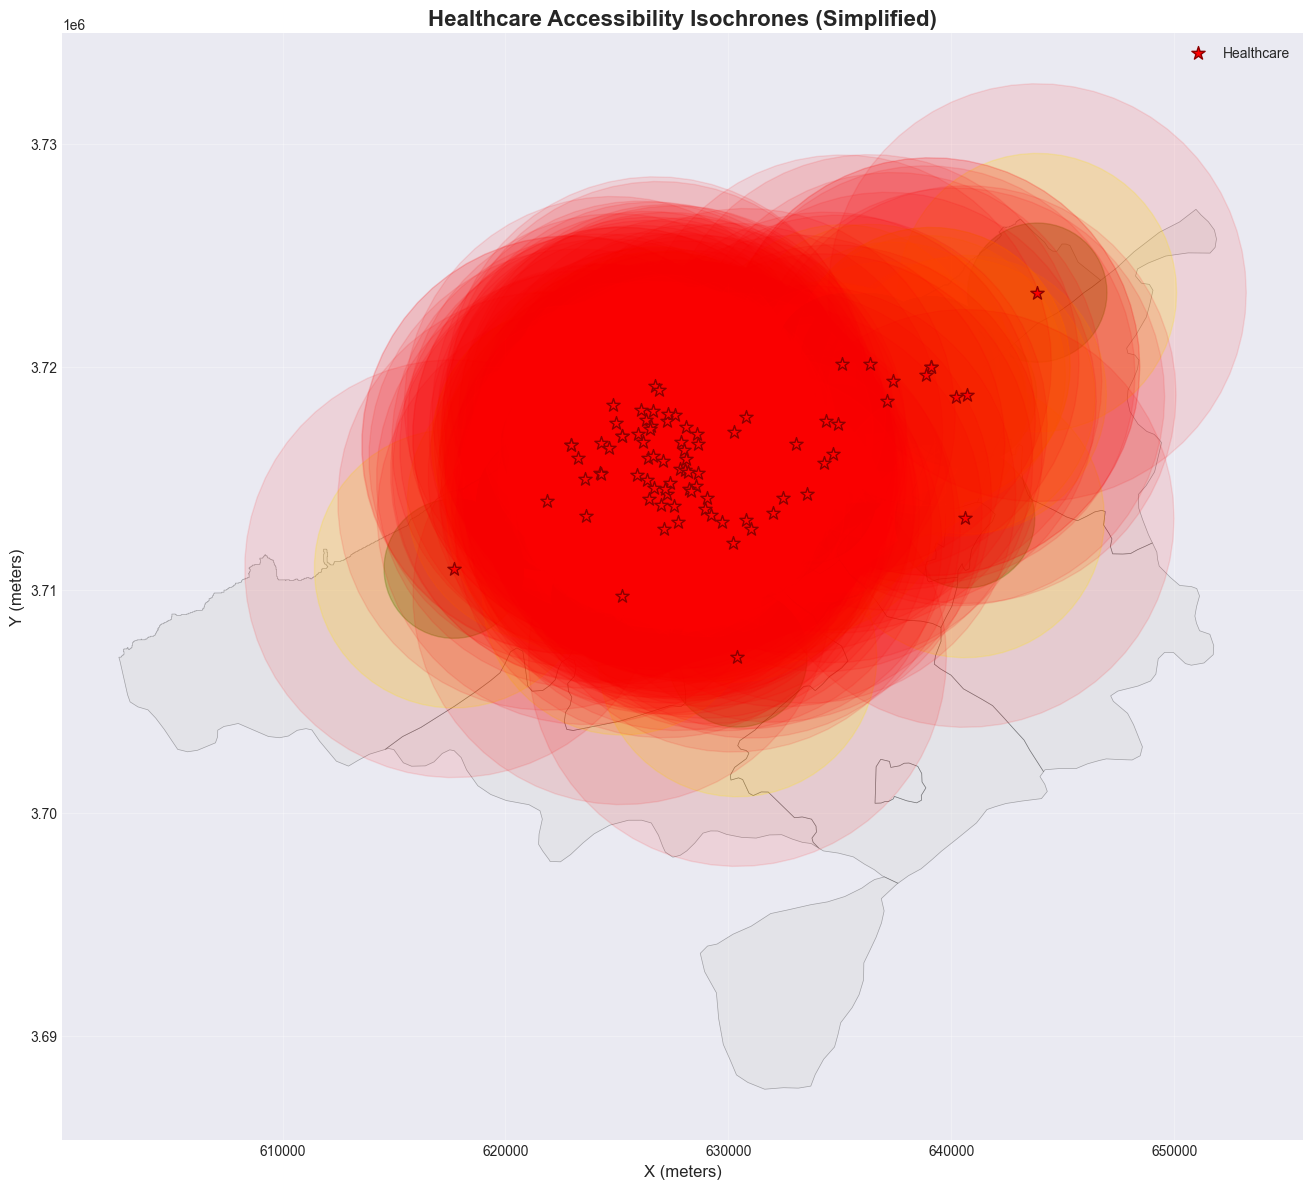

✓ Isochrone map created


In [ ]:
def create_isochrones(center_point, travel_time_minutes, speed_m_min, num_points=64):
    """
    Create circular isochrone (simplified) around a point.
    In reality, isochrones follow the road network, but this provides a visualization.
    """
    # Calculate radius
    radius = travel_time_minutes * speed_m_min
    
    # Create circle
    angles = np.linspace(0, 2*np.pi, num_points)
    x = center_point.x + radius * np.cos(angles)
    y = center_point.y + radius * np.sin(angles)
    
    return Polygon(zip(x, y))

# Create isochrones for each healthcare facility
print("Creating isochrones for healthcare facilities...")

isochrone_times = [15, 30, 45]  # minutes
colors = ['green', 'yellow', 'red']
alphas = [0.3, 0.2, 0.1]

# Use combined speed (walking + transit average)
AVERAGE_SPEED = (WALKING_SPEED_M_MIN + BUS_SPEED_M_MIN) / 2

fig, ax = plt.subplots(figsize=(15, 12))

# Plot districts
districts_gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.5)

# Plot isochrones
for time, color, alpha in zip(isochrone_times, colors, alphas):
    isochrones = []
    for idx, row in healthcare_gdf.iterrows():
        isochrone = create_isochrones(row.geometry, time, AVERAGE_SPEED)
        isochrones.append(isochrone)
    
    isochrone_gdf = gpd.GeoDataFrame(geometry=isochrones, crs=healthcare_gdf.crs)
    isochrone_gdf.plot(ax=ax, color=color, alpha=alpha, edgecolor=color, 
                        linewidth=1, label=f'{time} min')

# Plot healthcare facilities
healthcare_gdf.plot(ax=ax, color='red', markersize=100, marker='*', 
                     edgecolor='darkred', linewidth=1, label='Healthcare', zorder=5)

ax.set_title('Healthcare Accessibility Isochrones (Simplified)', fontsize=16, fontweight='bold')
ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Isochrone map created")

## 7. Accessibility Visualization

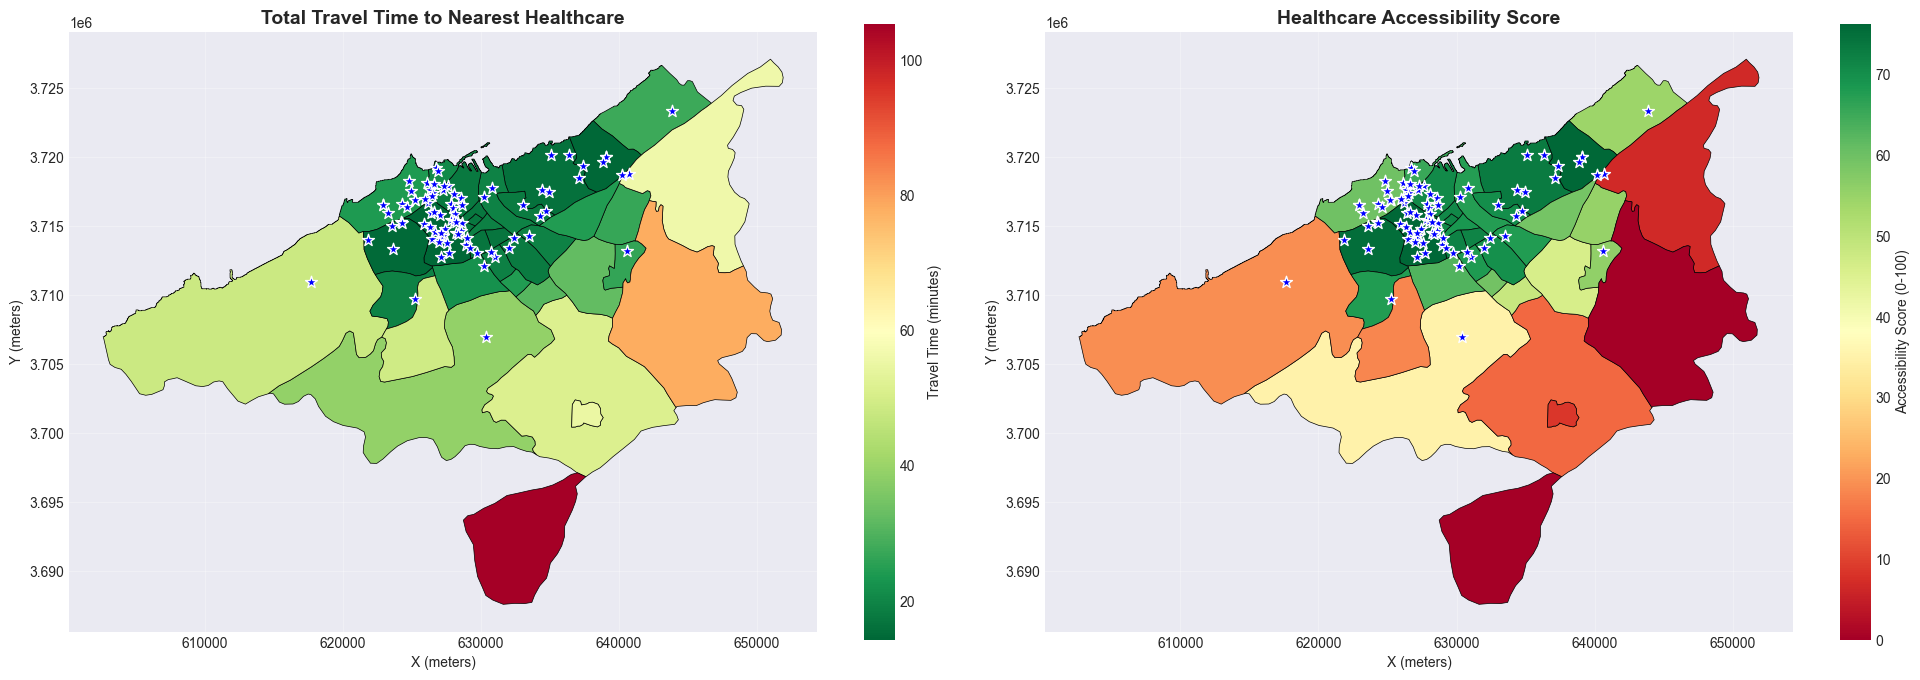

✓ Accessibility maps created


In [ ]:
# Create accessibility choropleth map
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Map 1: Travel time
districts_gdf.plot(column='total_travel_time_min', ax=axes[0], legend=True, 
                    cmap='RdYlGn_r', edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Travel Time (minutes)', 'shrink': 0.8})
healthcare_gdf.plot(ax=axes[0], color='blue', markersize=80, marker='*', 
                     edgecolor='white', linewidth=1, zorder=5)
axes[0].set_title('Total Travel Time to Nearest Healthcare', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X (meters)')
axes[0].set_ylabel('Y (meters)')
axes[0].grid(True, alpha=0.3)

# Map 2: Accessibility score
districts_gdf.plot(column='accessibility_score', ax=axes[1], legend=True, 
                    cmap='RdYlGn', edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Accessibility Score (0-100)', 'shrink': 0.8})
healthcare_gdf.plot(ax=axes[1], color='blue', markersize=80, marker='*', 
                     edgecolor='white', linewidth=1, zorder=5)
axes[1].set_title('Healthcare Accessibility Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X (meters)')
axes[1].set_ylabel('Y (meters)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Accessibility maps created")

## 8. Equity Analysis

Analyze accessibility in relation to population

EQUITY ANALYSIS

Total population: 5,102,619
Population with poor accessibility (<50 score): 1,214,540
Percentage affected: 23.8%

Population-weighted average travel time: 27.1 minutes


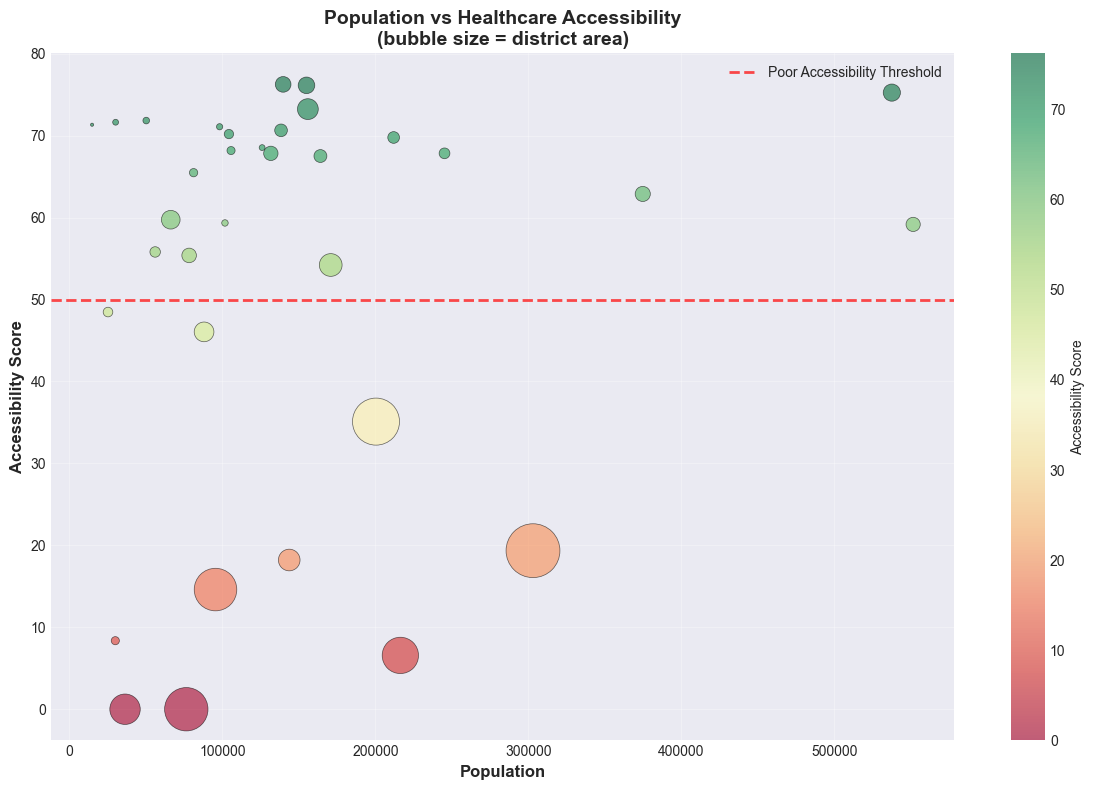

In [ ]:
# Population-weighted accessibility
if 'population' in districts_gdf.columns:
    # Calculate population with poor accessibility
    poor_access = districts_gdf['accessibility_score'] < 50
    pop_poor_access = districts_gdf[poor_access]['population'].sum()
    total_pop = districts_gdf['population'].sum()
    
    print("=" * 60)
    print("EQUITY ANALYSIS")
    print("=" * 60)
    print(f"\nTotal population: {total_pop:,.0f}")
    print(f"Population with poor accessibility (<50 score): {pop_poor_access:,.0f}")
    print(f"Percentage affected: {100 * pop_poor_access / total_pop:.1f}%")
    
    # Calculate weighted average travel time
    weighted_travel_time = np.average(
        districts_gdf['total_travel_time_min'].fillna(60),
        weights=districts_gdf['population']
    )
    print(f"\nPopulation-weighted average travel time: {weighted_travel_time:.1f} minutes")
    
    # Scatter plot: Population vs Accessibility
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(districts_gdf['population'], 
                         districts_gdf['accessibility_score'],
                         c=districts_gdf['accessibility_score'],
                         s=districts_gdf['area_km2']*10,
                         cmap='RdYlGn', alpha=0.6, edgecolor='black', linewidth=0.5)
    
    ax.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.7, 
               label='Poor Accessibility Threshold')
    
    ax.set_xlabel('Population', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accessibility Score', fontsize=12, fontweight='bold')
    ax.set_title('Population vs Healthcare Accessibility\n(bubble size = district area)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Accessibility Score', fontsize=10)
    
    plt.tight_layout()
    plt.show()

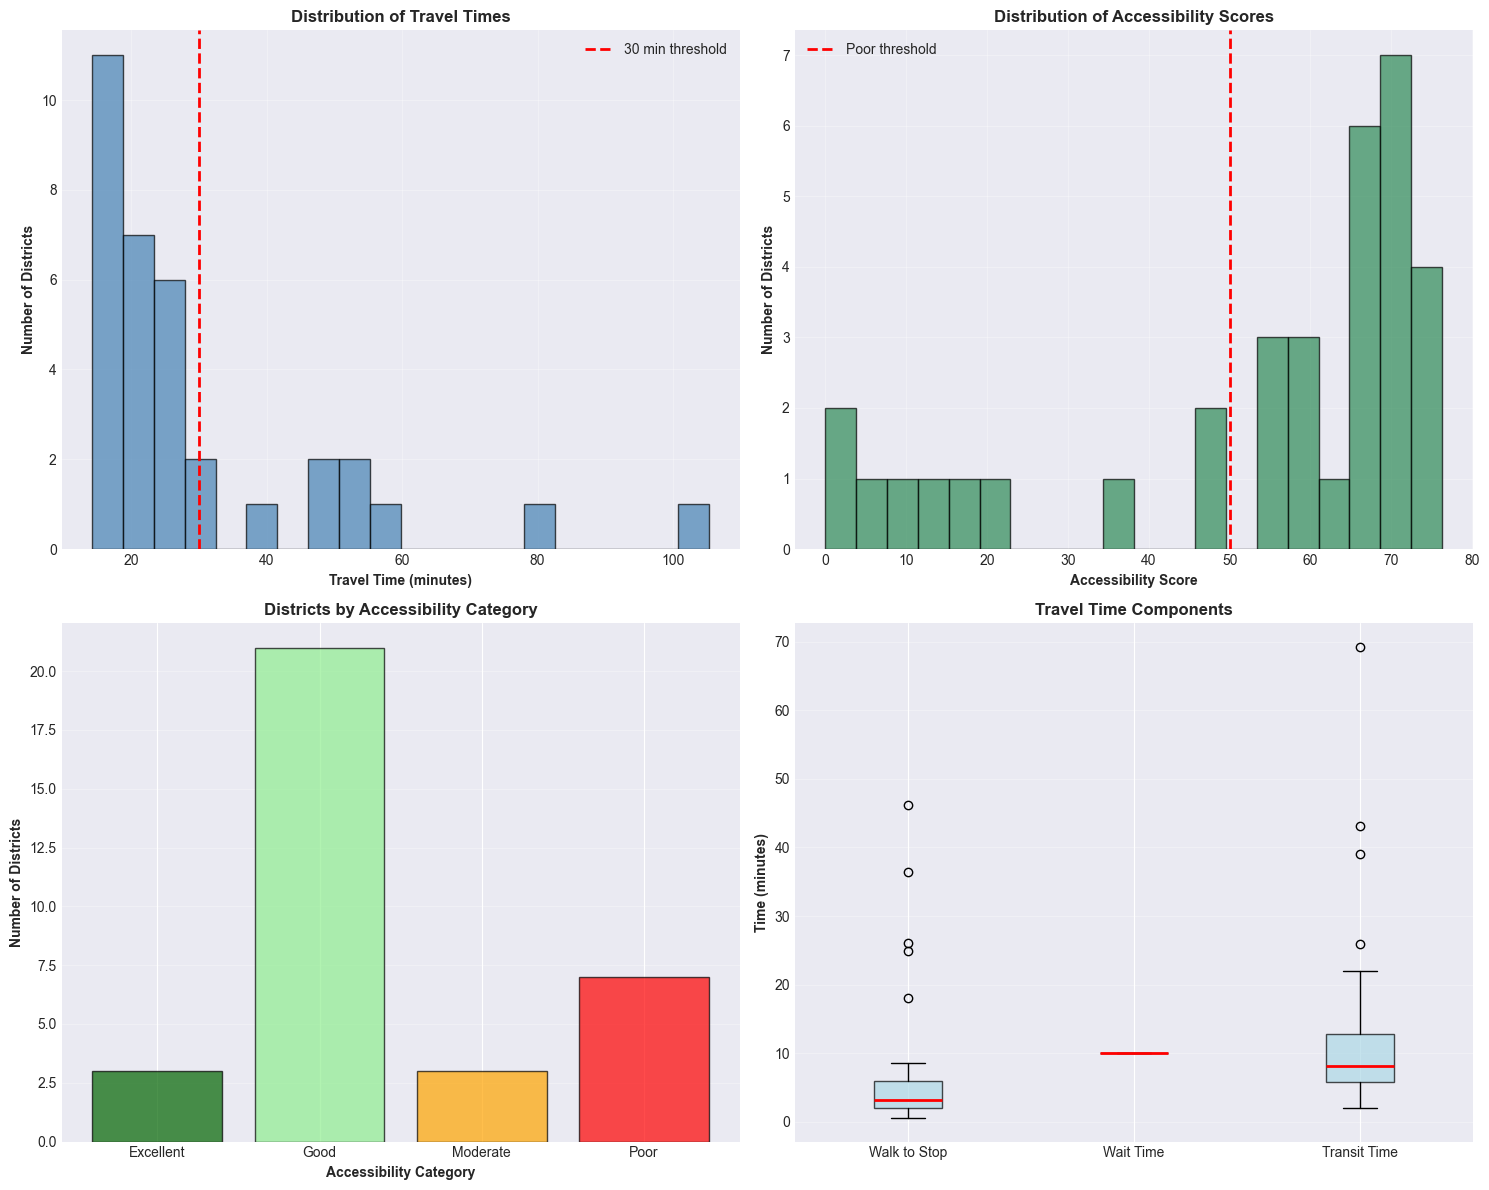

✓ Statistical visualizations created


In [ ]:
# Distribution of travel times
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram: Travel times
axes[0, 0].hist(districts_gdf['total_travel_time_min'].dropna(), bins=20, 
                color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=30, color='red', linestyle='--', linewidth=2, label='30 min threshold')
axes[0, 0].set_xlabel('Travel Time (minutes)', fontweight='bold')
axes[0, 0].set_ylabel('Number of Districts', fontweight='bold')
axes[0, 0].set_title('Distribution of Travel Times', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Histogram: Accessibility scores
axes[0, 1].hist(districts_gdf['accessibility_score'].dropna(), bins=20, 
                color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Poor threshold')
axes[0, 1].set_xlabel('Accessibility Score', fontweight='bold')
axes[0, 1].set_ylabel('Number of Districts', fontweight='bold')
axes[0, 1].set_title('Distribution of Accessibility Scores', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bar chart: Accessibility categories
category_counts = districts_gdf['accessibility_category'].value_counts()
category_order = ['Excellent', 'Good', 'Moderate', 'Poor']
category_counts = category_counts.reindex(category_order, fill_value=0)
colors_cat = ['darkgreen', 'lightgreen', 'orange', 'red']

axes[1, 0].bar(category_counts.index, category_counts.values, color=colors_cat, 
               edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Accessibility Category', fontweight='bold')
axes[1, 0].set_ylabel('Number of Districts', fontweight='bold')
axes[1, 0].set_title('Districts by Accessibility Category', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Box plot: Travel time components
walk_times = districts_gdf['walk_time_to_stop_min'].dropna()
transit_times = (districts_gdf['total_travel_time_min'] - 
                 districts_gdf['walk_time_to_stop_min'] - WAIT_TIME).dropna()

data_to_plot = [walk_times, [WAIT_TIME]*len(districts_gdf), transit_times]
axes[1, 1].boxplot(data_to_plot, labels=['Walk to Stop', 'Wait Time', 'Transit Time'],
                   patch_artist=True, 
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Time (minutes)', fontweight='bold')
axes[1, 1].set_title('Travel Time Components', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Statistical visualizations created")

## 10. Summary Statistics and Rankings

In [ ]:
# Create summary table
district_col = 'district' if 'district' in districts_gdf.columns else 'commune'

summary_cols = [district_col, 'population', 'area_km2', 'pop_density',
                'walk_time_to_stop_min', 'total_travel_time_min', 
                'accessibility_score', 'accessibility_category']

summary_cols = [col for col in summary_cols if col in districts_gdf.columns]

summary_df = districts_gdf[summary_cols].copy()
summary_df = summary_df.sort_values('accessibility_score', ascending=False)

print("=" * 80)
print("DISTRICT ACCESSIBILITY RANKINGS")
print("=" * 80)
print("\nTop 10 Most Accessible Districts:")
print("=" * 80)
display(summary_df.head(10))

print("\n" + "=" * 80)
print("Bottom 10 Least Accessible Districts:")
print("=" * 80)
display(summary_df.tail(10))

DISTRICT ACCESSIBILITY RANKINGS

Top 10 Most Accessible Districts:


,district,population,area_km2,pop_density,walk_time_to_stop_min,total_travel_time_min,accessibility_score,accessibility_category
14,El Maarif,139669,12.752223,10952.521578,2.056654,14.244115,76.259809,Excellent
27,Sidi Bernoussi,154919,14.305715,10829.168651,2.313767,14.314478,76.142536,Excellent
15,Hay Hassani,537509,15.345164,35027.908231,2.200685,14.846799,75.255334,Excellent
7,Ain Sebaa,155828,22.503784,6924.524449,2.155548,16.055346,73.241090,Good
13,Bou Chentouf,50184,2.292988,21885.854100,1.815816,16.894120,71.843134,Good
9,Al Idrissia,30167,1.793358,16821.517748,1.898941,17.016542,71.639096,Good
18,Machouar Casablanca,14784,0.517974,28541.945877,0.854307,17.199158,71.334736,Good
20,Mers Sultan,98139,2.029881,48347.178434,1.451668,17.347059,71.088235,Good
26,Sidi Belyout,138294,8.351846,16558.494904,3.266509,17.610834,70.648611,Good
16,Hay Mohammadi,104232,4.524223,23038.652888,2.419450,17.882497,70.195839,Good



Bottom 10 Least Accessible Districts:


,district,population,area_km2,pop_density,walk_time_to_stop_min,total_travel_time_min,accessibility_score,accessibility_category
24,Salmia,25189,4.777272,5272.674466,5.305001,30.915965,48.473391,Moderate
3,Mediouna,87977,20.113394,4374.050354,3.727404,32.367412,46.054314,Moderate
0,Bouskoura,200359,114.679467,1747.121824,3.078520,38.938620,35.102300,Moderate
1,Bouskoura,302970,150.399340,2014.437029,24.889798,48.390391,19.349348,Poor
28,Sidi Maarouf,143647,24.265195,5919.878362,18.128095,49.073217,18.211305,Poor
2,Mediouna,95457,93.849070,1017.133152,2.122915,51.237001,14.604998,Poor
19,Mediouna,29972,3.436402,8721.912421,1.869356,54.980953,8.365078,Poor
32,Tit Mellil,216281,68.428257,3160.697197,36.347097,56.058990,6.568350,Poor
23,Nouaceur,36326,48.051315,755.983467,26.021407,105.300861,0.000000,Poor
33,Tit Mellil,76362,97.623424,782.209814,46.241207,78.253429,0.000000,Poor


In [ ]:
# Overall statistics
print("=" * 80)
print("OVERALL ACCESSIBILITY STATISTICS")
print("=" * 80)

print(f"\nStudy Area:")
print(f"  Total districts: {len(districts_gdf)}")
print(f"  Total area: {districts_gdf['area_km2'].sum():.2f} km²")
if 'population' in districts_gdf.columns:
    print(f"  Total population: {districts_gdf['population'].sum():,.0f}")
    print(f"  Average population density: {districts_gdf['pop_density'].mean():.1f} per km²")

print(f"\nHealthcare Infrastructure:")
print(f"  Healthcare facilities: {len(healthcare_gdf)}")
print(f"  Transport stops: {len(transport_gdf)}")

print(f"\nAccessibility Metrics:")
print(f"  Average travel time: {districts_gdf['total_travel_time_min'].mean():.1f} minutes")
print(f"  Median travel time: {districts_gdf['total_travel_time_min'].median():.1f} minutes")
print(f"  Average accessibility score: {districts_gdf['accessibility_score'].mean():.1f}")
print(f"  Districts with excellent access (score ≥75): {(districts_gdf['accessibility_score'] >= 75).sum()}")
print(f"  Districts with poor access (score <50): {(districts_gdf['accessibility_score'] < 50).sum()}")

if 'population' in districts_gdf.columns:
    print(f"\nPopulation-Weighted Metrics:")
    print(f"  Weighted avg travel time: {weighted_travel_time:.1f} minutes")
    print(f"  Population with poor access: {pop_poor_access:,.0f} ({100*pop_poor_access/total_pop:.1f}%)")

OVERALL ACCESSIBILITY STATISTICS

Study Area:
  Total districts: 34
  Total area: 837.67 km²
  Total population: 5,102,619
  Average population density: 18671.3 per km²

Healthcare Infrastructure:
  Healthcare facilities: 84
  Transport stops: 1463

Accessibility Metrics:
  Average travel time: 30.0 minutes
  Median travel time: 21.5 minutes
  Average accessibility score: 53.1
  Districts with excellent access (score ≥75): 3
  Districts with poor access (score <50): 10

Population-Weighted Metrics:
  Weighted avg travel time: 27.1 minutes
  Population with poor access: 1,214,540 (23.8%)


## 11. Export Results

In [ ]:
# Export results to GeoPackage and CSV
output_gpkg = '../data/processed/accessibility_results.gpkg'
output_csv = '../data/processed/accessibility_results.csv'

# Save to GeoPackage
districts_gdf.to_file(output_gpkg, driver='GPKG', layer='district_accessibility')
print(f"✓ Results saved to: {output_gpkg}")

# Save summary to CSV (without geometry)
summary_export = districts_gdf.drop(columns=['geometry', 'centroid']).copy()
summary_export.to_csv(output_csv, index=False)
print(f"✓ Summary saved to: {output_csv}")

print("\n✓ Analysis complete!")

## 12. Key Findings and Recommendations

### Methodology Summary:
This analysis used a **time-based accessibility approach** rather than simple distance buffers:

1. **Walking time to transport stops**: Calculated from district centroids to nearest bus stops
2. **Transit time**: Network-based routing between stops and healthcare facilities
3. **Wait and transfer times**: Incorporated realistic time penalties
4. **Total accessibility score**: Composite metric (0-100) based on total travel time

### Key Advantages of Time-Based Approach:
- More realistic representation of actual accessibility
- Accounts for public transport network structure
- Identifies areas where transport infrastructure is lacking
- Better for equity analysis (poor areas often have worse transit)

### Potential Improvements:
1. **GTFS Data Integration**: Use real transit schedules for accurate travel times
2. **Road Network**: Incorporate actual road network for precise routing
3. **Peak/Off-peak Analysis**: Different accessibility at different times of day
4. **Multi-modal Analysis**: Include walking-only scenarios
5. **Healthcare Capacity**: Weight facilities by size/services offered

---

### Next Steps:
1. Identify priority areas for new healthcare facilities
2. Recommend transport service improvements
3. Validate results with community input
4. Compare with other cities for benchmarking